# Tutorial using HBC Data

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import ot
import torch
import pandas as pd
import numpy as np
import scanpy as sc
from scipy.sparse import csr_matrix
import sklearn
from sklearn import metrics
import multiprocessing as mp
from SC2CD_py import SC2CD
import SC2CD_py.CARD_utils as CARD
from SC2CD_py.utils import clustering

In [5]:
# Run device, by default, the package is implemented on 'cpu'. We recommend using GPU.
## For window, set the following:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
## For Mac, set device = torch.device('mps')

# the location of R, which is necessary for mclust algorithm. Please replace the path below with local R installation path
os.environ['R_HOME'] = '/Users/lyy/miniconda3/envs/scanpy_env/lib/R'

### Import necessary code from R

In [3]:
import rpy2.robjects as ro
from rpy2.robjects import r
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
pandas2ri.activate()

# path_local is where this .iphnb exists
path_local='/Users/lyy/Documents/CARD-master/'

# the path for your python environment
path_py='/Users/lyy/miniconda3/envs/scanpy_env/bin/python3.8'

# load the necessary R package to python
CARD.R_load(path_local,path_py)

R[write to console]: 
Attaching package: ‘dplyr’


R[write to console]: The following objects are masked from ‘package:stats’:

    filter, lag


R[write to console]: The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


R[write to console]: Loading required package: spam

R[write to console]: Spam version 2.10-0 (2023-10-23) is loaded.
Type 'help( Spam)' or 'demo( spam)' for a short introduction 
and overview of this package.
Help for individual functions is also obtained by adding the
suffix '.spam' to the function name, e.g. 'help( chol.spam)'.

R[write to console]: 
Attaching package: ‘spam’


R[write to console]: The following objects are masked from ‘package:base’:

    backsolve, forwardsolve


R[write to console]: Loading required package: viridisLite

R[write to console]: 
Try help(fields) to get started.

R[write to console]: 
Attaching package: ‘gtools’


R[write to console]: The following object is masked _by_ ‘.GlobalEnv’:

    lo


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

## Round 0

### Initial Spatial Clustering (GraphST)

In [6]:
# with cell dec
path = "Data/3.Human_Breast_Cancer/"
adata = sc.read_visium(path, count_file = "filtered_feature_bc_matrix.h5")
adata.var_names_make_unique()

df = pd.read_csv('Data/3.Human_Breast_Cancer/metadata.tsv',sep='\t',index_col=0)
gg=df['ground_truth'].values
adata.obs['ground_truth']=gg
df['ground_truth'].to_csv('Data/3.Human_Breast_Cancer/cluster_result/ground_truth.csv')
# we save the ground_truth result for CARD implementation

position = adata.obsm['spatial']
adata.obsm['distance_matrix']= ot.dist(position, position, metric='euclidean')

SC2CD.preprocess(adata)
SC2CD.construct_interaction(adata)
SC2CD.add_contrastive_label(adata)

model=SC2CD.SC2CD(adata,device=device)
adata=model.train()

Begin to train ST data...


100%|████████████████████████████████████████████████████████████████████████████████| 600/600 [01:39<00:00,  6.04it/s]


Optimization finished for ST data!


In [5]:
radius = 50
n_cluster=20
tool = 'mclust' # mclust, leiden, and louvain

if tool == 'mclust':
   clustering(adata, n_cluster, radius=radius, method=tool, refinement=True) # For DLPFC dataset, we use optional refinement step.
elif tool in ['leiden', 'louvain']:
   clustering(adata, n_cluster, radius=radius, method=tool, start=0.1, end=2.5, increment=0.01, refinement=True)

domain=adata.obs['domain']
domain.to_csv('Data/3.Human_Breast_Cancer/cluster_result/round0.csv')

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


Method: GraphST_ini leiden
Cluster Number: 20
Refined Radius:-- (No refinement)
ARI: 0.5053551107268803
NMI: 0.6472167097969534
Method: GraphST_ini refined
Cluster Number: 20
Lambda: 0 ;  Refined Radius: 50
ARI: 0.5262386471564507
NMI: 0.669594197815665


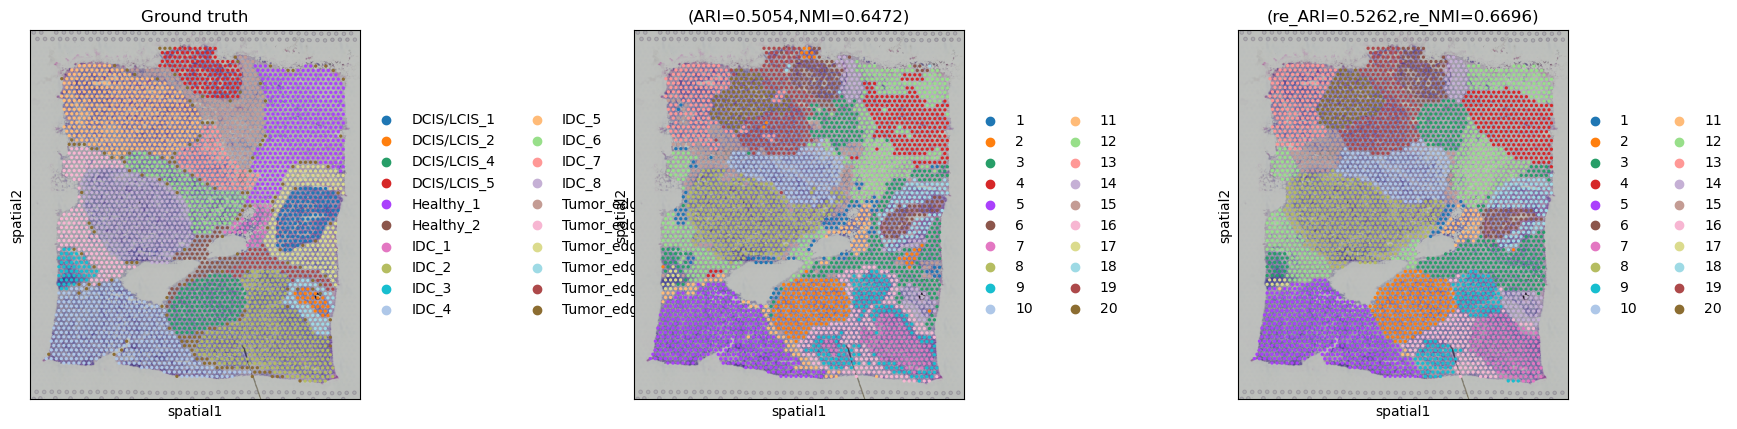

In [6]:
# calculate metric ARI
ARI = metrics.adjusted_rand_score(adata.obs[tool][np.where(pd.isnull(gg)==False)[0]], adata.obs['ground_truth'][np.where(pd.isnull(gg)==False)[0]])
adata.uns['ARI'] = ARI
NMI=metrics.normalized_mutual_info_score(adata.obs['ground_truth'][np.where(pd.isnull(gg)==False)[0]],adata.obs[tool][np.where(pd.isnull(gg)==False)[0]])
adata.uns['NMI'] = NMI
print('Method: GraphST_ini leiden')
print('Cluster Number:', n_cluster)
print('Refined Radius:-- (No refinement)')
print('ARI:', ARI)
print('NMI:', NMI)

# calculate metric ARI
re_ARI = metrics.adjusted_rand_score(adata.obs['domain'][np.where(pd.isnull(gg)==False)[0]], adata.obs['ground_truth'][np.where(pd.isnull(gg)==False)[0]])
adata.uns['re_ARI'] = re_ARI
re_NMI=metrics.normalized_mutual_info_score(adata.obs['ground_truth'][np.where(pd.isnull(gg)==False)[0]],adata.obs['domain'][np.where(pd.isnull(gg)==False)[0]])
adata.uns['re_NMI'] = re_NMI
print('Method: GraphST_ini refined')
print('Cluster Number:', n_cluster)
print('Lambda:', 0,';  Refined Radius:',radius)
print('ARI:', re_ARI)
print('NMI:', re_NMI)

sc.pl.spatial(adata,
              img_key="hires",
              color=["ground_truth", tool, "domain"],
              title=["Ground truth", "(ARI=%.4f,NMI=%.4f)"%(ARI, NMI), "(re_ARI=%.4f,re_NMI=%.4f)"%(re_ARI, re_NMI)],
              show=True,save='HBC_round0.png')

### Initial Cell Decomposition (CARD)

In [7]:
pred=pd.read_csv('Data/3.Human_Breast_Cancer/cluster_result/round0.csv',index_col=0)
ground=pd.read_csv('Data/3.Human_Breast_Cancer/cluster_result/ground_truth.csv',index_col=0)
path = "Data/3.Human_Breast_Cancer/"
adata = sc.read_visium(path, count_file = "filtered_feature_bc_matrix.h5")
adata.var_names_make_unique()
CARD.Gen_Imput(path,adata.var.index)
CARD.Set_Obj(pred['domain'])

## QC on scRNASeq dataset! ...
## QC on spatially-resolved dataset! ...


In [8]:
lam_cell_dec = 0  ### Means Initial CARD
cell_result=CARD.Get_Dec(lam_c=lam_cell_dec)
cell_result.to_csv(f'Data/3.Human_Breast_Cancer/cell_dec/round0.csv')

## create reference matrix from scRNASeq...
## Select Informative Genes! ...
## Deconvolution Starts! ...
## Deconvolution Finish! ...


## Round 1

Begin to train ST data...


100%|█████████████████████████████████████████| 600/600 [03:14<00:00,  3.08it/s]

Optimization finished for ST data!


fitting ...
  |======================================================================| 100%


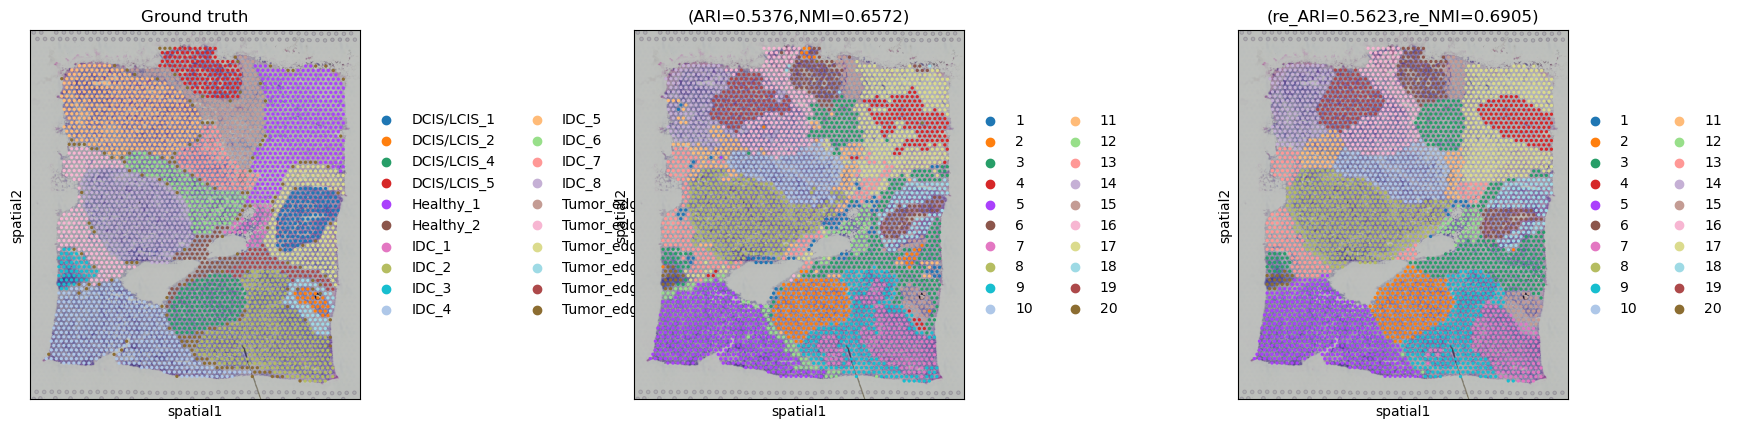

In [9]:
path = "Data/3.Human_Breast_Cancer/"
radius = 50
n_cluster = 20
tool = 'mclust'
lam_spatial_cluster = 0.1

df = pd.read_csv('Data/3.Human_Breast_Cancer/metadata.tsv',sep='\t')
gg = df['ground_truth'].values

adata = sc.read_visium(path, count_file = "filtered_feature_bc_matrix.h5")
adata.var_names_make_unique()
adata.obs['ground_truth']=gg
position = adata.obsm['spatial']
distance=ot.dist(position, position, metric='euclidean')
adata.obsm['distance_matrix'] = distance


cell_dec=pd.read_csv(f'Data/3.Human_Breast_Cancer/cell_dec/round0.csv',index_col=0)

if(cell_dec.shape[0] != adata.obs.shape[0]):
    df = pd.DataFrame(0, index=adata.obs_names, columns=cell_dec.columns) 
    df.loc[cell_dec.index] = cell_dec.loc[cell_dec.index]
    main_list = np.setdiff1d(adata.obs_names, cell_dec.index)
    for obs in main_list:
        ind = np.where(adata.obs_names == obs)
        vec  = distance[ind[0], :]
        index = vec.argsort()
        prop_mean = df.iloc[index[0][1]]
        for j in range(2, 9):
            prop_mean += df.iloc[index[0][j]]
        prop_mean /= 8
        df.iloc[ind[0]] = prop_mean
    cell_dec = df 
    
adata.obsm['cell_weight_matrix']=ot.dist(np.array(cell_dec), metric='cosine')

SC2CD.preprocess(adata)
SC2CD.construct_interaction(adata,cell_dec=cell_dec,lam=lam_spatial_cluster)
SC2CD.add_contrastive_label(adata)

model=SC2CD.SC2CD(adata,device=device,cell_dec=cell_dec,lam=lam_spatial_cluster)
adata=model.train()

if tool == 'mclust':
   clustering(adata, n_cluster, radius=radius, method=tool, refinement=True) # For DLPFC dataset, we use optional refinement step.
elif tool in ['leiden', 'louvain']:
   clustering(adata, n_cluster, radius=radius, method=tool, start=0.1, end=2, increment=0.01, refinement=True)

domain=adata.obs['domain']
domain.to_csv(f'Data/3.Human_Breast_Cancer/cluster_result/round1.csv')

ARI = metrics.adjusted_rand_score(adata.obs[tool][np.where(pd.isnull(gg)==False)[0]], adata.obs['ground_truth'][np.where(pd.isnull(gg)==False)[0]])
adata.uns['ARI'] = ARI
NMI=metrics.normalized_mutual_info_score(adata.obs['ground_truth'][np.where(pd.isnull(gg)==False)[0]],adata.obs[tool][np.where(pd.isnull(gg)==False)[0]])
adata.uns['NMI'] = NMI
re_ARI = metrics.adjusted_rand_score(adata.obs['domain'][np.where(pd.isnull(gg)==False)[0]], adata.obs['ground_truth'][np.where(pd.isnull(gg)==False)[0]])
adata.uns['re_ARI'] = re_ARI
re_NMI=metrics.normalized_mutual_info_score(adata.obs['ground_truth'][np.where(pd.isnull(gg)==False)[0]],adata.obs['domain'][np.where(pd.isnull(gg)==False)[0]])
adata.uns['re_NMI'] = re_NMI

sc.pl.spatial(adata,
              img_key="hires",
              color=["ground_truth", tool, "domain"],
              title=["Ground truth", "(ARI=%.4f,NMI=%.4f)"%(ARI, NMI), "(re_ARI=%.4f,re_NMI=%.4f)"%(re_ARI, re_NMI)],
              show=True,save=f'HBC_round1.png')

In [10]:
pred=pd.read_csv('Data/3.Human_Breast_Cancer/cluster_result/round1.csv',index_col=0)
ground=pd.read_csv('Data/3.Human_Breast_Cancer/cluster_result/ground_truth.csv',index_col=0)

path = "Data/3.Human_Breast_Cancer/"
adata = sc.read_visium(path, count_file = "filtered_feature_bc_matrix.h5")
adata.var_names_make_unique()
CARD.Gen_Imput(path,adata.var.index)
CARD.Set_Obj(pred['domain'])
lam_cell_dec = 10
cell_result=CARD.Get_Dec(lam_c=lam_cell_dec)
cell_result.to_csv(f'Data/3.Human_Breast_Cancer/cell_dec/round1.csv')

## QC on scRNASeq dataset! ...
## QC on spatially-resolved dataset! ...
## create reference matrix from scRNASeq...
## Select Informative Genes! ...
## Deconvolution Starts! ...
## Deconvolution Finish! ...


### Self-Evaluation of cell decompsition

In [12]:
def m_CARD(clu, cell_dec):
    unique_clusters = np.unique(clu)
    Eva_Var={}
    Eva_Var_sum={}
    for ci in unique_clusters:
        cell = cell_dec[clu == ci]  # No scaling since scale=False in R
        #variance = np.sum(cell**2, axis=0)
        Eva_Var[f'Cluster_{ci}']= cell.var()*(cell.shape[0]-1)/cell.shape[0]
        Eva_Var_sum[f'Cluster_{ci}']= cell.var()*(cell.shape[0]-1)
        
    H = pd.DataFrame(Eva_Var_sum).sum(axis=1)/(cell_dec.shape[0]-1) # global mean of distance to the cluster
    return H.sum()

In [18]:
round_times = 1
H_collect = {}
for i in range(round_times+1):
    cell_dec=pd.read_csv(f'Data/3.Human_Breast_Cancer/cell_dec/round{i}.csv',index_col=0)
    H_collect[f'Round{i}']= {'H':m_CARD(pred['domain'], cell_dec), 'H_g':m_CARD(ground['ground_truth'],cell_dec)}
H_data=pd.DataFrame(H_collect)
H_data

,Round0,Round1
H,0.075254,0.073754
H_g,0.070493,0.069348


- $H_g$ is a supervised evaluation metric; 
- $H$ is an unsupervised evaluation metric:
    - it has a similar trend to the supervised evaluation metric $H_g$
    - can be used to signal the termination of the iterative algorithm 


## Round 2

### Spatial Clustering with Cell Decomposition Result from Round1

Begin to train ST data...


100%|█████████████████████████████████████████| 600/600 [03:21<00:00,  2.97it/s]

Optimization finished for ST data!


fitting ...
  |======================================================================| 100%


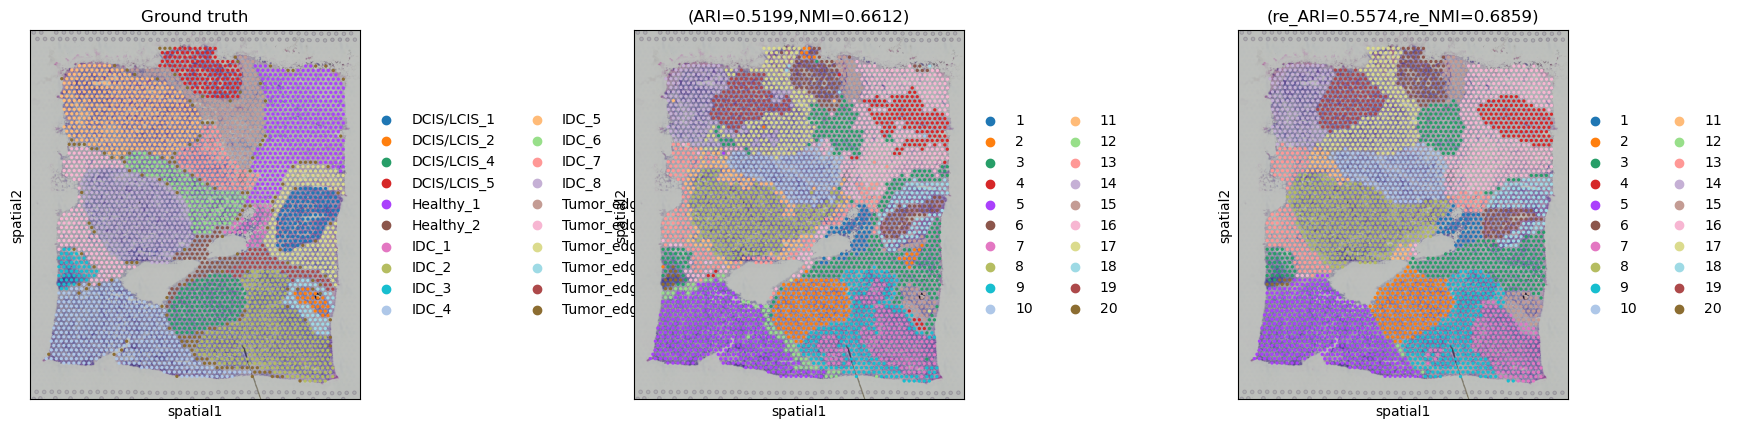

In [14]:
path = "Data/3.Human_Breast_Cancer/"
radius = 50
n_cluster = 20
tool = 'mclust'
lam_spatial_cluster = 0.1

df = pd.read_csv('Data/3.Human_Breast_Cancer/metadata.tsv',sep='\t')
gg = df['ground_truth'].values

adata = sc.read_visium(path, count_file = "filtered_feature_bc_matrix.h5")
adata.var_names_make_unique()
adata.obs['ground_truth']=gg
position = adata.obsm['spatial']
distance=ot.dist(position, position, metric='euclidean')
adata.obsm['distance_matrix'] = distance


cell_dec=pd.read_csv(f'Data/3.Human_Breast_Cancer/cell_dec/round1.csv',index_col=0)

if(cell_dec.shape[0] != adata.obs.shape[0]):
    df = pd.DataFrame(0, index=adata.obs_names, columns=cell_dec.columns) 
    df.loc[cell_dec.index] = cell_dec.loc[cell_dec.index]
    main_list = np.setdiff1d(adata.obs_names, cell_dec.index)
    for obs in main_list:
        ind = np.where(adata.obs_names == obs)
        vec  = distance[ind[0], :]
        index = vec.argsort()
        prop_mean = df.iloc[index[0][1]]
        for j in range(2, 9):
            prop_mean += df.iloc[index[0][j]]
        prop_mean /= 8
        df.iloc[ind[0]] = prop_mean
    cell_dec = df 
    
adata.obsm['cell_weight_matrix']=ot.dist(np.array(cell_dec), metric='cosine')

SC2CD.preprocess(adata)
SC2CD.construct_interaction(adata,cell_dec=cell_dec,lam=lam_spatial_cluster)
SC2CD.add_contrastive_label(adata)

model=SC2CD.SC2CD(adata,device=device,cell_dec=cell_dec,lam=lam_spatial_cluster)
adata=model.train()

if tool == 'mclust':
   clustering(adata, n_cluster, radius=radius, method=tool, refinement=True) # For DLPFC dataset, we use optional refinement step.
elif tool in ['leiden', 'louvain']:
   clustering(adata, n_cluster, radius=radius, method=tool, start=0.1, end=2, increment=0.01, refinement=True)

domain=adata.obs['domain']
domain.to_csv(f'Data/3.Human_Breast_Cancer/cluster_result/round2.csv')

ARI = metrics.adjusted_rand_score(adata.obs[tool][np.where(pd.isnull(gg)==False)[0]], adata.obs['ground_truth'][np.where(pd.isnull(gg)==False)[0]])
adata.uns['ARI'] = ARI
NMI=metrics.normalized_mutual_info_score(adata.obs['ground_truth'][np.where(pd.isnull(gg)==False)[0]],adata.obs[tool][np.where(pd.isnull(gg)==False)[0]])
adata.uns['NMI'] = NMI
re_ARI = metrics.adjusted_rand_score(adata.obs['domain'][np.where(pd.isnull(gg)==False)[0]], adata.obs['ground_truth'][np.where(pd.isnull(gg)==False)[0]])
adata.uns['re_ARI'] = re_ARI
re_NMI=metrics.normalized_mutual_info_score(adata.obs['ground_truth'][np.where(pd.isnull(gg)==False)[0]],adata.obs['domain'][np.where(pd.isnull(gg)==False)[0]])
adata.uns['re_NMI'] = re_NMI

sc.pl.spatial(adata,
              img_key="hires",
              color=["ground_truth", tool, "domain"],
              title=["Ground truth", "(ARI=%.4f,NMI=%.4f)"%(ARI, NMI), "(re_ARI=%.4f,re_NMI=%.4f)"%(re_ARI, re_NMI)],
              show=True,save=f'HBC_round2.png')

### Cell Decomposition with Spatial Clustering Result from Round2

In [15]:
pred=pd.read_csv('Data/3.Human_Breast_Cancer/cluster_result/round2.csv',index_col=0)
ground=pd.read_csv('Data/3.Human_Breast_Cancer/cluster_result/ground_truth.csv',index_col=0)

path = "Data/3.Human_Breast_Cancer/"
adata = sc.read_visium(path, count_file = "filtered_feature_bc_matrix.h5")
adata.var_names_make_unique()
CARD.Gen_Imput(path,adata.var.index)
CARD.Set_Obj(pred['domain'])
lam_cell_dec = 10
cell_result=CARD.Get_Dec(lam_c=lam_cell_dec)
cell_result.to_csv(f'Data/3.Human_Breast_Cancer/cell_dec/round2.csv')

## QC on scRNASeq dataset! ...
## QC on spatially-resolved dataset! ...
## create reference matrix from scRNASeq...
## Select Informative Genes! ...
## Deconvolution Starts! ...
## Deconvolution Finish! ...


### Self-Evaluation of cell decompsition

In [19]:
round_times = 2
H_collect = {}
for i in range(round_times+1):
    cell_dec=pd.read_csv(f'Data/3.Human_Breast_Cancer/cell_dec/round{i}.csv',index_col=0)
    H_collect[f'Round{i}']= {'H':m_CARD(pred['domain'], cell_dec), 'H_g':m_CARD(ground['ground_truth'],cell_dec)}
H_data=pd.DataFrame(H_collect)
H_data

,Round0,Round1,Round2
H,0.075254,0.073754,0.073734
H_g,0.070493,0.069348,0.069380


H shows no significant decrease in Round2 compared with that in Round1, we stop the iterative algorithm in Round2

Final result for HBC:

- cell decomposition: Round1
- spatial clustering: Round1